# Bài 1: Cài đặt Canny từ Đầu
1. Cài đặt toàn bộ pipeline Canny từ đầu bằng NumPy (không dùng cv2.Canny ở phần cốt lõi).

2. Cài đặt Otsu để tự động xác định τ high; so sánh kết quả với τ chỉnhtay
khi nào Otsu tốthơn,khi nào tệhơn? Giảithích.

3. So sánh implementation của bạn với cv2. Canny bằng chỉ số IoU (Inter section over Union).

4. Trả lời: nếu kết quả có quá nhiều cạnh giả, bạn điều chỉnh tham số nào trước tiên và theo hướng nào? Giải thích dựa trên cơ chế thuật toán.

In [2]:
import numpy as np
import cv2
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import convolve

# Bài 1 – Cài đặt Canny Từ Đầu
**Môn:** Xử lý ảnh và Thị giác máy tính (121036)  
**Pipeline:** Gaussian Blur → Sobel → NMS → Otsu → Hysteresis  
> Toàn bộ cài đặt bằng **NumPy thuần**, không dùng `cv2.Canny` ở phần cốt lõi.

## 1. Gaussian Blur
**Mục đích:** làm mờ ảnh trước khi tính gradient, triệt tiêu nhiễu cao tần.  
Dùng *separable filter* (tích chập 1D theo hàng rồi cột) để tăng tốc.

$$G(x,y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2+y^2}{2\sigma^2}}$$

In [3]:
#yeu cau 1
def gaussian_blur(image: np.ndarray, sigma: float = 1.0) -> np.ndarray:
    """Gaussian blur dùng separable 1D kernel – thuần NumPy."""
    size = int(6 * sigma + 1) | 1   # kích thước lẻ
    k = size // 2
    x = np.arange(-k, k + 1, dtype=np.float64)
    g1d = np.exp(-x**2 / (2 * sigma**2))
    g1d /= g1d.sum()

    img = image.astype(np.float64)
    # Tích chập theo hàng rồi theo cột
    tmp = np.apply_along_axis(lambda r: np.convolve(r, g1d, mode='same'), 1, img)
    return np.apply_along_axis(lambda c: np.convolve(c, g1d, mode='same'), 0, tmp)

## 2. Sobel Gradient → M và θ
Kernel Sobel kết hợp đạo hàm hữu hạn + làm mịn Gaussian 1D theo chiều vuông góc:

$$G_x = \begin{bmatrix}-1&0&+1\\-2&0&+2\\-1&0&+1\end{bmatrix}*I \qquad
G_y = \begin{bmatrix}-1&-2&-1\\0&0&0\\+1&+2&+1\end{bmatrix}*I$$

$$M = \sqrt{G_x^2 + G_y^2}, \qquad \theta = \arctan\!\left(\frac{G_y}{G_x}\right)$$

> **Lưu ý:** θ vuông góc với đường cạnh thật, không phải song song.

In [4]:
#yeu cau 1
SOBEL_X = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float64)

SOBEL_Y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float64)

def sobel_gradient(image: np.ndarray):
    """Tính Gx, Gy, magnitude M và hướng theta (độ)."""
    Gx = convolve(image.astype(np.float64), SOBEL_X)
    Gy = convolve(image.astype(np.float64), SOBEL_Y)
    M  = np.hypot(Gx, Gy)
    theta = np.degrees(np.arctan2(Gy, Gx))   # [-180, 180]
    return Gx, Gy, M, theta

## 3. Non-maximum Suppression (NMS)
Giữ chỉ pixel có M là **cực đại cục bộ** dọc theo hướng gradient.

**Thuật toán:**
1. Lượng tử hoá θ về 4 hướng: 0°, 45°, 90°, 135°
2. Xác định 2 hàng xóm q1, q2 dọc theo hướng đó
3. Nếu M(p) < max(M(q1), M(q2)) → xoá p

Kết quả: cạnh dày 3–5 px → mỏng 1 px.

In [5]:
#yeu cau 1
def non_maximum_suppression(M: np.ndarray, theta: np.ndarray) -> np.ndarray:
    """NMS: chỉ giữ pixel là cực đại cục bộ dọc hướng gradient."""
    H, W = M.shape
    nms   = np.zeros_like(M)
    angle = theta % 180   # chuẩn hoá về [0, 180)

    for i in range(1, H - 1):
        for j in range(1, W - 1):
            a = angle[i, j]
            m = M[i, j]

            if   (0   <= a < 22.5) or (157.5 <= a < 180): q1, q2 = M[i, j-1], M[i, j+1]
            elif  22.5 <= a < 67.5:                         q1, q2 = M[i-1, j+1], M[i+1, j-1]
            elif  67.5 <= a < 112.5:                        q1, q2 = M[i-1, j],   M[i+1, j]
            else:                                            q1, q2 = M[i-1, j-1], M[i+1, j+1]

            if m >= q1 and m >= q2:
                nms[i, j] = m

    return nms

## 4. Otsu Thresholding (tự động chọn ngưỡng)
Otsu tìm τ* tối đa hoá **phương sai liên lớp** (between-class variance):

$$\tau^* = \arg\max_{\tau}\; \omega_0(\tau)\,\omega_1(\tau)\,\bigl[\mu_0(\tau) - \mu_1(\tau)\bigr]^2$$

Áp dụng lên histogram của M (sau NMS):  
→ `τhigh = τ*_Otsu`, `τlow = τhigh / 2`

In [6]:
#yeu cau 2
def otsu_threshold(M: np.ndarray, n_bins: int = 256):
    """Trả về (tau_high, tau_low) tự động từ histogram gradient M."""
    M_norm = M / M.max() * 255 if M.max() > 0 else M
    hist, _ = np.histogram(M_norm.flatten(), bins=n_bins, range=(0, 256))
    hist   = hist.astype(np.float64)
    total  = hist.sum()

    best_tau, best_var = 0, 0.0
    sum_total = np.dot(np.arange(n_bins), hist)
    sum_bg, w_bg = 0.0, 0.0

    for t in range(n_bins):
        w_bg  += hist[t];  sum_bg += t * hist[t]
        if w_bg == 0: continue
        w_fg = total - w_bg
        if w_fg == 0: break

        mu_bg = sum_bg / w_bg
        mu_fg = (sum_total - sum_bg) / w_fg
        var_b = w_bg * w_fg * (mu_bg - mu_fg) ** 2

        if var_b > best_var:
            best_var, best_tau = var_b, t

    tau_high = best_tau / 255.0 * M.max()
    return tau_high, tau_high / 2.0

## 5. Hysteresis Thresholding (DFS)
Phân loại pixel thành 3 nhóm:
- **Strong edge** (≥ τhigh): giữ chắc chắn
- **Weak edge** (τlow ≤ M < τhigh): giữ nếu **kết nối 8-chiều** với strong edge
- **Noise** (< τlow): loại bỏ

Dùng **DFS** (stack) để lan truyền đúng thứ tự — tránh lỗi single-pass.

In [7]:
#yeu cau 1
def hysteresis_thresholding(nms: np.ndarray,
                             tau_low: float,
                             tau_high: float) -> np.ndarray:
    """Edge tracking bằng DFS 8-connectivity."""
    H, W   = nms.shape
    strong = nms >= tau_high
    weak   = (nms >= tau_low) & ~strong
    result = np.zeros((H, W), dtype=np.uint8)
    result[strong] = 255

    visited = strong.copy()
    stack   = list(zip(*np.where(strong)))
    dirs    = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]

    while stack:
        ci, cj = stack.pop()
        for di, dj in dirs:
            ni, nj = ci+di, cj+dj
            if 0 <= ni < H and 0 <= nj < W and not visited[ni,nj] and weak[ni,nj]:
                visited[ni,nj] = True
                result[ni,nj]  = 255
                stack.append((ni, nj))
    return result

## 6. Pipeline Canny Đầy Đủ
Gộp tất cả bước trên vào một hàm duy nhất. Trả về dict chứa mọi bước trung gian.

In [8]:
#yeu cau 1
def canny_from_scratch(image: np.ndarray,
                       sigma: float = 1.0,
                       tau_low: float = None,
                       tau_high: float = None,
                       use_otsu: bool = True) -> dict:
    """Pipeline Canny đầy đủ — thuần NumPy."""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image
    gray = gray.astype(np.float64)

    blurred       = gaussian_blur(gray, sigma)
    _, _, M, theta = sobel_gradient(blurred)
    nms           = non_maximum_suppression(M, theta)

    if use_otsu or tau_high is None:
        th_auto, tl_auto = otsu_threshold(nms)
        th = tau_high if tau_high is not None else th_auto
        tl = tau_low  if tau_low  is not None else tl_auto
    else:
        th, tl = tau_high, tau_low

    edges = hysteresis_thresholding(nms, tl, th)

    return dict(gray=gray, blurred=blurred, M=M, theta=theta,
                nms=nms, tau_low=tl, tau_high=th, edges=edges)

## 7. Chỉ số IoU (Intersection over Union)
So sánh edge map của implementation với `cv2.Canny`:

$$\text{IoU} = \frac{|\text{pred} \cap \text{gt}|}{|\text{pred} \cup \text{gt}|}$$

In [9]:
#yeu cau 3
def compute_iou(pred: np.ndarray, gt: np.ndarray) -> float:
    p, g = pred > 0, gt > 0
    return (p & g).sum() / (p | g).sum() if (p | g).sum() > 0 else 1.0

## 8. Demo – Chạy Pipeline và Visualize
Tạo ảnh test tổng hợp (hình chữ nhật + đường tròn + đường thẳng + nhiễu Gaussian).

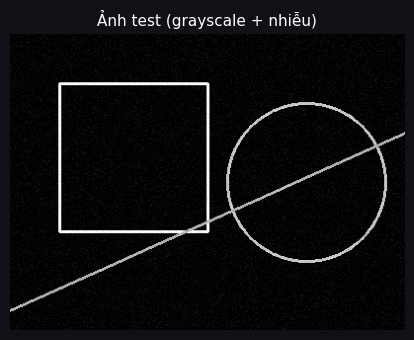

Kích thước ảnh: (300, 400)


In [10]:
# ── Tạo ảnh test ───────────────────────────────────────────────
img_gray = np.zeros((300, 400), dtype=np.uint8)
cv2.rectangle(img_gray, (50, 50),  (200, 200), 255, 2)
cv2.circle(   img_gray, (300, 150), 80,        200, 2)
cv2.line(     img_gray, (0, 280),  (400, 100), 180, 2)
noise = np.random.normal(0, 10, img_gray.shape).astype(np.int16)
img_gray = np.clip(img_gray.astype(np.int16) + noise, 0, 255).astype(np.uint8)

plt.figure(figsize=(5, 3.5), facecolor='#0f1117')
ax = plt.gca(); ax.set_facecolor('#0f1117')
ax.imshow(img_gray, cmap='gray')
ax.set_title('Ảnh test (grayscale + nhiễu)', color='white', fontsize=11)
ax.axis('off')
plt.tight_layout()
plt.savefig('step0_input.png', dpi=110, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()
print(f'Kích thước ảnh: {img_gray.shape}')

In [11]:
# ── yeu cau 2 - so sánh Otsu vs tay
# ── Chạy phần Otsu + NMS trước (chưa hysteresis) ────────────────
SIGMA = 1.4

result_otsu = canny_from_scratch(img_gray, sigma=SIGMA, use_otsu=True)
th_o, tl_o  = result_otsu['tau_high'], result_otsu['tau_low']
print(f'Otsu tự động → τhigh = {th_o:.1f},  τlow = {tl_o:.1f}')

Otsu tự động → τhigh = 172.5,  τlow = 86.3


### 8.1. Nhìn Histogram để Tự Chọn Ngưỡng Tay
Theo tài liệu (mục 1.5): *"Luôn visualise histogram trước khi tin vào kết quả Otsu"*.

Trục y dùng log scale để các đỉnh nhỏ không bị che bởi đỉnh nền khổng lồ
(vùng phẳng luôn có số pixel gấp hàng chục–hàng trăm lần vùng cạnh).  
Đường đỏ nét đứt là gợi ý của Otsu; bạn tự **nhìn bằng mắt** và chọn τhigh phù hợp.

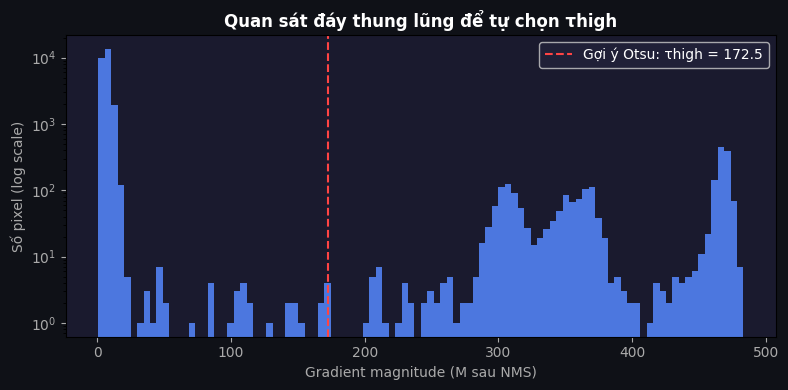

Gợi ý cách đọc:
  - Đỉnh bên trái (gần 0): pixel vùng phẳng, không phải cạnh.
  - Đỉnh bên phải (giá trị cao hơn): pixel cạnh thật.
  - τhigh nên đặt tại điểm THẤP NHẤT giữa hai đỉnh (đáy thung lũng), NẾU CÓ.
  - M lớn nhất trong ảnh: 483.4


In [12]:
# ── Vẽ histogram để chọn ngưỡng TAY bằng quan sát (log scale) ──
M_flat_preview = result_otsu['nms'].flatten()
M_flat_preview = M_flat_preview[M_flat_preview > 0]

plt.figure(figsize=(8, 4), facecolor='#0f1117')
ax = plt.gca(); ax.set_facecolor('#1a1a2e')
ax.tick_params(colors='#aaaaaa')
ax.hist(M_flat_preview, bins=100, color='#5588ff', alpha=0.85, edgecolor='none')
ax.set_yscale('log')   # log scale — quan trọng để thấy đỉnh nhỏ
ax.axvline(th_o, color='#ff4444', lw=1.5, ls='--',
           label=f'Gợi ý Otsu: τhigh = {th_o:.1f}')
ax.set_xlabel('Gradient magnitude (M sau NMS)', color='#aaaaaa')
ax.set_ylabel('Số pixel (log scale)', color='#aaaaaa')
ax.set_title('Quan sát đáy thung lũng để tự chọn τhigh',
              color='white', fontweight='bold')
ax.legend(facecolor='#22223a', labelcolor='white')
plt.tight_layout()
plt.show()

print('Gợi ý cách đọc:')
print('  - Đỉnh bên trái (gần 0): pixel vùng phẳng, không phải cạnh.')
print('  - Đỉnh bên phải (giá trị cao hơn): pixel cạnh thật.')
print('  - τhigh nên đặt tại điểm THẤP NHẤT giữa hai đỉnh (đáy thung lũng), NẾU CÓ.')
print(f'  - M lớn nhất trong ảnh: {M_flat_preview.max():.1f}')

### 8.2. Tự Đặt Giá Trị Ngưỡng Tay
Sau khi nhìn histogram ở trên, **tự điền số bạn quan sát được** vào hai biến dưới đây.
Nếu chưa chắc, có thể thử lần lượt 2–3 giá trị rồi xem ảnh kết quả ở bước sau —
đây chính là cách "chỉnh tay" thật sự (thử – quan sát – tinh chỉnh), khác với
Otsu (tính tự động từ công thức phương sai liên lớp).

In [13]:
# ── Tự chọn ngưỡng tay (THAY SỐ Ở ĐÂY sau khi nhìn histogram) ───
# Gợi ý: nhìn đồ thị ở trên, ước lượng giá trị M tại đáy thung lũng.
# Số mẫu dưới đây CHỈ LÀ VÍ DỤ KHỞI ĐẦU — hãy sửa lại theo ảnh thật của bạn.
TAU_HIGH_MANUAL = 150.0   # ← bạn tự đặt theo đáy thung lũng quan sát được
TAU_LOW_MANUAL  = TAU_HIGH_MANUAL / 2   # tỷ lệ 1:2 theo gợi ý tài liệu (mục 1.5)

print(f'Ngưỡng tay bạn chọn → τhigh = {TAU_HIGH_MANUAL:.1f},  τlow = {TAU_LOW_MANUAL:.1f}')
print(f'(So với Otsu tự động  → τhigh = {th_o:.1f},  τlow = {tl_o:.1f})')

Ngưỡng tay bạn chọn → τhigh = 150.0,  τlow = 75.0
(So với Otsu tự động  → τhigh = 172.5,  τlow = 86.3)


In [14]:
# ── Chạy hysteresis với ngưỡng tay vừa chọn + so sánh cv2 ───────
th_m, tl_m = TAU_HIGH_MANUAL, TAU_LOW_MANUAL
result_man = canny_from_scratch(img_gray, sigma=SIGMA,
                                 tau_high=th_m, tau_low=tl_m, use_otsu=False)

blurred_cv = cv2.GaussianBlur(img_gray, (0,0), SIGMA)
cv2_th     = int(np.clip(th_o * 2, 0, 255))
edges_cv2  = cv2.Canny(blurred_cv, cv2_th // 2, cv2_th)

iou_otsu = compute_iou(result_otsu['edges'], edges_cv2)
iou_man  = compute_iou(result_man['edges'],  edges_cv2)
print(f'IoU (Otsu vs cv2) = {iou_otsu:.4f}')
print(f'IoU (Tay  vs cv2) = {iou_man:.4f}')

IoU (Otsu vs cv2) = 0.6839
IoU (Tay  vs cv2) = 0.6829


## 9. Visualize – Các Bước Pipeline

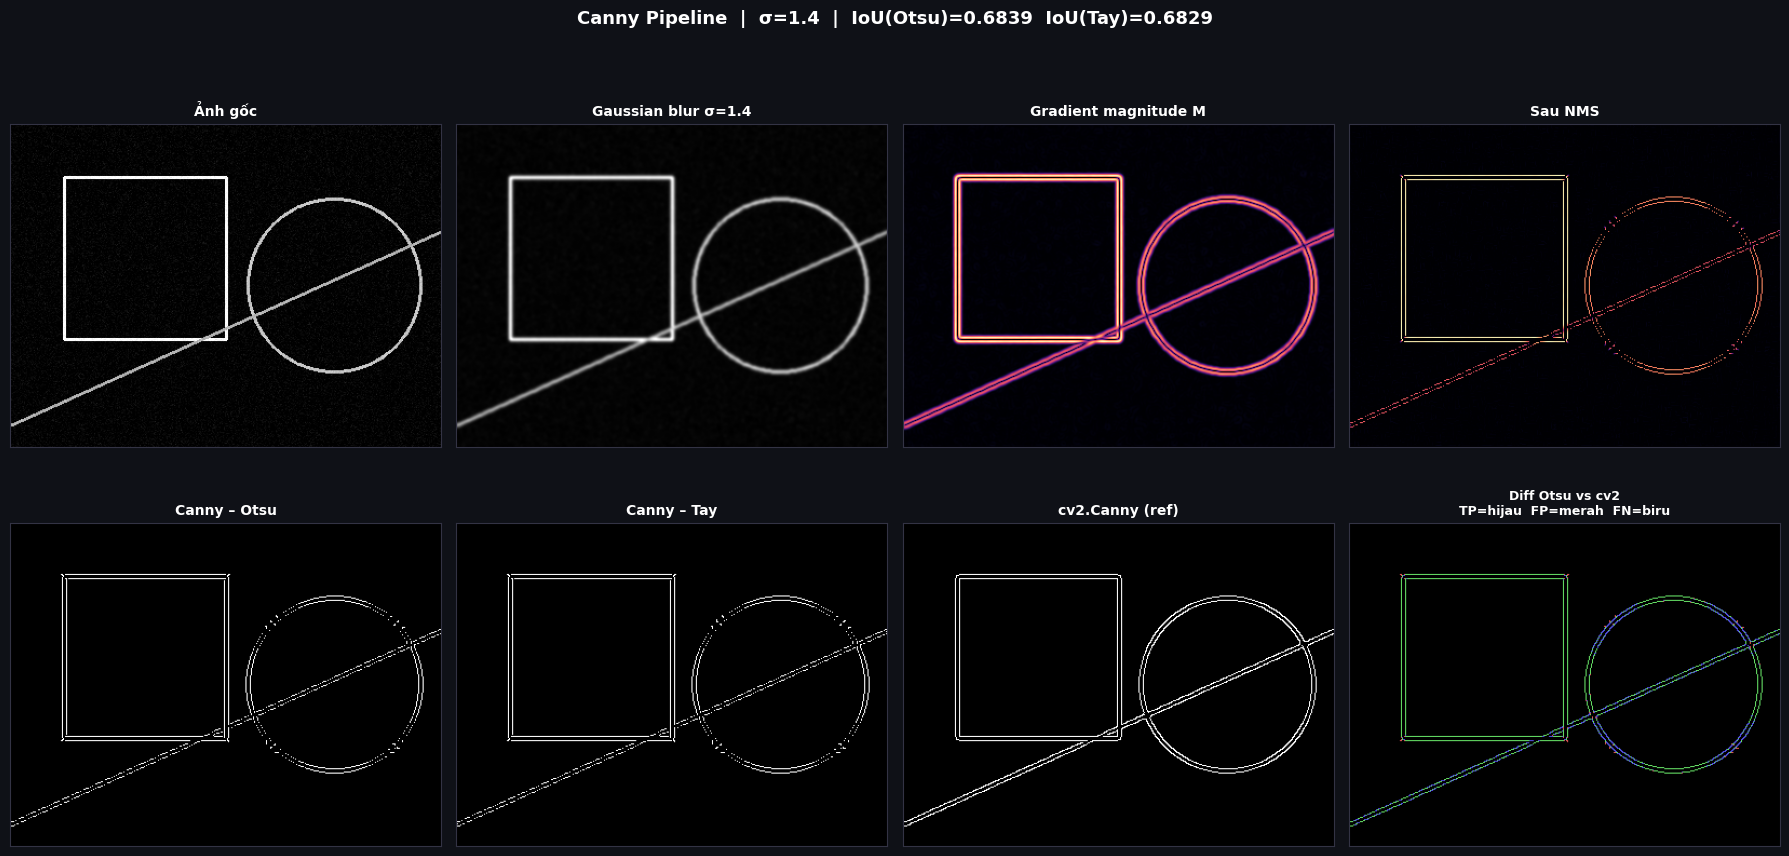

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9), facecolor='#0f1117')
fig.patch.set_facecolor('#0f1117')

steps = [
    (img_gray,                   'Ảnh gốc',              'gray'),
    (result_otsu['blurred'],     f'Gaussian blur σ={SIGMA}','gray'),
    (result_otsu['M'],           'Gradient magnitude M', 'magma'),
    (result_otsu['nms'],         'Sau NMS',              'magma'),
    (result_otsu['edges'],       'Canny – Otsu',         'gray'),
    (result_man['edges'],        'Canny – Tay',          'gray'),
    (edges_cv2,                  'cv2.Canny (ref)',       'gray'),
    (None,                       'Diff Otsu vs cv2',      None),
]

for idx, (ax, (data, title, cmap)) in enumerate(zip(axes.flat, steps)):
    ax.set_facecolor('#1a1a2e')
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('#333344')
    if data is None:
        diff = np.zeros((*img_gray.shape, 3), dtype=np.uint8)
        p = result_otsu['edges'] > 0;  g = edges_cv2 > 0
        diff[p & g]   = [100, 220, 100]   # TP
        diff[p & ~g]  = [220, 80,  80 ]   # FP
        diff[~p & g]  = [80,  80,  220]   # FN
        ax.imshow(diff)
        ax.set_title('Diff Otsu vs cv2\nTP=hijau  FP=merah  FN=biru',
                     color='white', fontsize=9, fontweight='bold')
    else:
        ax.imshow(data, cmap=cmap)
        ax.set_title(title, color='white', fontsize=10, fontweight='bold')

fig.suptitle(f'Canny Pipeline  |  σ={SIGMA}  |  IoU(Otsu)={iou_otsu:.4f}  IoU(Tay)={iou_man:.4f}',
             color='white', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('canny_pipeline.png', dpi=120, bbox_inches='tight',
            facecolor='#0f1117')
plt.show()

## 10. Histogram Gradient M + Đường Ngưỡng Otsu

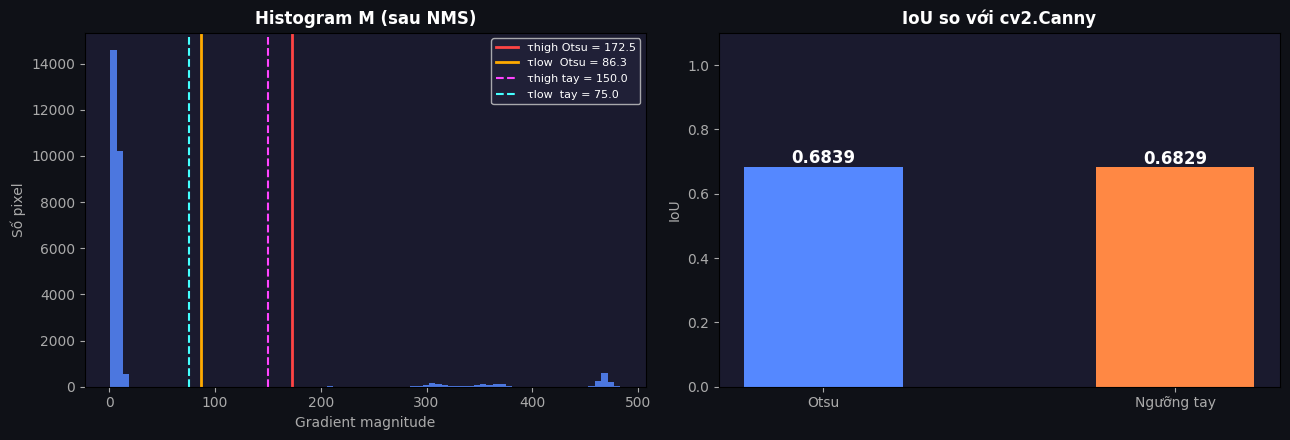

In [16]:
#yeu cau 2- yeu cau 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#0f1117')
fig.patch.set_facecolor('#0f1117')

for ax in (ax1, ax2):
    ax.set_facecolor('#1a1a2e')
    ax.tick_params(colors='#aaaaaa')

# Histogram
M_flat = result_otsu['nms'].flatten()
M_flat = M_flat[M_flat > 0]
ax1.hist(M_flat, bins=80, color='#5588ff', alpha=0.85, edgecolor='none')
ax1.axvline(th_o, color='#ff4444', lw=2, label=f'τhigh Otsu = {th_o:.1f}')
ax1.axvline(tl_o, color='#ffaa00', lw=2, label=f'τlow  Otsu = {tl_o:.1f}')
ax1.axvline(th_m, color='#ff44ff', lw=1.5, ls='--', label=f'τhigh tay = {th_m:.1f}')
ax1.axvline(tl_m, color='#44ffff', lw=1.5, ls='--', label=f'τlow  tay = {tl_m:.1f}')
ax1.set_xlabel('Gradient magnitude', color='#aaaaaa')
ax1.set_ylabel('Số pixel',           color='#aaaaaa')
ax1.set_title('Histogram M (sau NMS)', color='white', fontweight='bold')
ax1.legend(fontsize=8, facecolor='#22223a', labelcolor='white', framealpha=0.8)

# IoU bar
bars = ax2.bar(['Otsu', 'Ngưỡng tay'], [iou_otsu, iou_man],
               color=['#5588ff','#ff8844'], width=0.45)
for bar, val in zip(bars, [iou_otsu, iou_man]):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.01,
             f'{val:.4f}', ha='center', color='white', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_title('IoU so với cv2.Canny', color='white', fontweight='bold')
ax2.set_ylabel('IoU', color='#aaaaaa')

plt.tight_layout()
plt.savefig('canny_histogram_iou.png', dpi=120,
            bbox_inches='tight', facecolor='#0f1117')
plt.show()

Yeu cau 2 - ## 11. Phân tích – Khi nào Otsu tốt hơn? Khi nào tệ hơn?

### Otsu tốt hơn khi:
- **Histogram bimodal rõ ràng**: vùng phẳng (gradient thấp) và vùng cạnh (gradient cao) tách biệt nhau.  
- Ảnh có đối tượng rõ nét trên nền đồng nhất (ví dụ: văn bản, bảng, đường kẻ).  
- Không cần thử-sai, tiết kiệm thời gian.

### Otsu tệ hơn khi:
- **Histogram unimodal**: ảnh kết cấu dày đặc (vải, cỏ, tường gạch) → không có "thung lũng" để phân tách.  
- Tỷ lệ pixel cạnh rất nhỏ (< 5%) → đỉnh cạnh bị "chìm" trong đỉnh nền, Otsu chọn ngưỡng quá cao.  
- Ảnh có nhiều mức gradient liên tục (ảnh y tế như MRI/CT).  

**Kết luận:** luôn visualise histogram M trước khi tin vào Otsu.  
Nếu histogram không rõ bimodal → điều chỉnh ngưỡng thủ công hoặc dùng percentile.

Yeu cau 4 - ## 12. Phân tích – Quá nhiều cạnh giả, điều chỉnh gì trước?

### Ưu tiên theo thứ tự:

**① Tăng `τhigh` (tác động mạnh nhất, ngay lập tức)**  
Hysteresis chỉ *promote* weak edge nếu nó **kết nối với strong edge**.  
Tăng `τhigh` → ít strong edge hơn → chuỗi DFS ngắn lại → phần lớn cạnh giả bị loại.  
Đây là điểm kiểm soát chính vì nó cắt ngay "gốc rễ" của chuỗi hysteresis.

**② Tăng `τlow` (loại weak edge cô lập yếu)**  
Nếu còn cạnh giả sau bước ①: tăng `τlow` → weak edge phải đủ mạnh hơn mới được promote.

**③ Tăng `σ` (nếu nhiễu lan rộng về không gian)**  
Gaussian kernel rộng hơn triệt tiêu gradient giả do nhiễu *trước* khi Sobel chạy.  
Hạn chế: σ lớn làm mờ chi tiết thật (nét mảnh, góc nhọn).

**Không nên** chỉnh Sobel kernel trước tiên — ảnh hưởng ít nhất đến cạnh giả.

```
Thứ tự thực tế: τhigh ↑  →  τlow ↑  →  σ ↑
```

# Bài 2: Multi-scale Hough Transform
1. Xây accumulator Hough từ đầu với ít nhất hai mức phân giải (coarse và fine).

2. Cài đặt coarse-to-fine: tìm ứng viên ở coarse, refine ở fine.

3. Cài đặt top-k peaks với NMS trên accumulator. So sánh kết quả khi k =1,3,5 trên ảnh bàn cờ– k nào phù hợp nhất và tại sao?

4. Cài đặt gradient-directed windowed voting. Vẽ đồ thị F1 vs window size (từ 5° đến 90°). Tìm và giải thích điểm “elbow”.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [3]:
def compute_sobel_gradient_vectorized(img_gray):
    img_gray = np.array(img_gray, dtype=np.float32)
    H, W = img_gray.shape
    
    img_blur = np.copy(img_gray)
    gaussian_kernel = np.array([
        [1,  4,  7,  4, 1],
        [4, 16, 26, 16, 4],
        [7, 26, 41, 26, 7],
        [4, 16, 26, 16, 4],
        [1,  4,  7,  4, 1]
    ], dtype=np.float32) / 273.0
    
    shape = (H - 4, W - 4, 5, 5)
    strides = (img_gray.strides[0], img_gray.strides[1], img_gray.strides[0], img_gray.strides[1])
    patches = np.lib.stride_tricks.as_strided(img_gray, shape=shape, strides=strides)
    img_blur[2:H-2, 2:W-2] = np.sum(patches * gaussian_kernel, axis=(2, 3))
    
    Kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
    Ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)
    
    shape_s = (H - 2, W - 2, 3, 3)
    strides_s = (img_blur.strides[0], img_blur.strides[1], img_blur.strides[0], img_blur.strides[1])
    patches_s = np.lib.stride_tricks.as_strided(img_blur, shape=shape_s, strides=strides_s)
    
    Gx = np.zeros_like(img_blur)
    Gy = np.zeros_like(img_blur)
    Gx[1:H-1, 1:W-1] = np.sum(patches_s * Kx, axis=(2, 3))
    Gy[1:H-1, 1:W-1] = np.sum(patches_s * Ky, axis=(2, 3))
    
    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx) * 180.0 / np.pi
    direction = direction % 180.0
    
    return magnitude, direction

In [4]:
def refine_to_fine_accumulator(edge_mask, grad_dir, coarse_peaks, window_size=20):
    y_idxs, x_idxs = np.where(edge_mask > 0)
    d_rho_c, d_theta_c = 8.0, 4.0 
    d_rho_f, d_theta_f = 0.5, 0.25 
    
    fine_lines = []
    for r_c, t_c, _ in coarse_peaks:
        rho_min, rho_max = r_c - d_rho_c, r_c + d_rho_c
        theta_min, theta_max = t_c - d_theta_c, t_c + d_theta_c
        
        rhos_f = np.arange(rho_min, rho_max, d_rho_f)
        thetas_f = np.arange(theta_min, theta_max, d_theta_f)
        if len(rhos_f) == 0 or len(thetas_f) == 0:
            continue
            
        accumulator_f = np.zeros((len(rhos_f), len(thetas_f)), dtype=np.int32)
        thetas_f_rad = np.radians(thetas_f)
        cos_t_f = np.cos(thetas_f_rad)
        sin_t_f = np.sin(thetas_f_rad)
        
        for x, y in zip(x_idxs, y_idxs):
            theta_actual = grad_dir[y, x]
            diff_t = abs(t_c - theta_actual)
            if min(diff_t, 180.0 - diff_t) > window_size:
                continue
            rho_check = x * np.cos(np.radians(t_c)) + y * np.sin(np.radians(t_c))
            if abs(rho_check - r_c) > d_rho_c * 1.5:
                continue
            
            for t_idx, theta_val in enumerate(thetas_f):
                rho = x * cos_t_f[t_idx] + y * sin_t_f[t_idx]
                if rho_min <= rho < rho_max:
                    r_idx = int((rho - rho_min) / d_rho_f)
                    if r_idx < accumulator_f.shape[0]:
                        accumulator_f[r_idx, t_idx] += 1
                        
        peaks_f = hough_peaks_with_nms(accumulator_f, rhos_f, thetas_f, k=1, min_dist_rho=1, min_dist_theta=1)
        if peaks_f:
            fine_lines.append(peaks_f[0])
            
    return fine_lines

def multi_scale_hough_pipeline(edge_mask, grad_dir, k=5, window_size=20):
    acc_c, rhos_c, thetas_c = build_coarse_accumulator(edge_mask, grad_dir, window_size)
    coarse_peaks = hough_peaks_with_nms(acc_c, rhos_c, thetas_c, k=k*2, min_dist_rho=2, min_dist_theta=2)
    fine_lines = refine_to_fine_accumulator(edge_mask, grad_dir, coarse_peaks, window_size)
    final_lines = sorted(fine_lines, key=lambda x: x[2], reverse=True)[:k]
    return final_lines

In [5]:
def build_coarse_accumulator(edge_mask, grad_dir, window_size=20):
    H, W = edge_mask.shape
    d_max = np.sqrt(H**2 + W**2)
    y_idxs, x_idxs = np.where(edge_mask > 0)
    
    d_rho_c, d_theta_c = 8.0, 4.0  
    rhos_c = np.arange(-d_max, d_max, d_rho_c)
    thetas_c = np.arange(0, 180, d_theta_c)
    
    accumulator_c = np.zeros((len(rhos_c), len(thetas_c)), dtype=np.int32)
    thetas_c_rad = np.radians(thetas_c)
    cos_t = np.cos(thetas_c_rad)
    sin_t = np.sin(thetas_c_rad)
    
    for x, y in zip(x_idxs, y_idxs):
        theta_actual = grad_dir[y, x]
        diff = np.abs(thetas_c - theta_actual)
        diff = np.minimum(diff, 180.0 - diff)
        valid_theta_indices = np.where(diff <= window_size)[0]
        
        for t_idx in valid_theta_indices:
            rho = x * cos_t[t_idx] + y * sin_t[t_idx]
            r_idx = np.argmin(np.abs(rhos_c - rho))
            accumulator_c[r_idx, t_idx] += 1
            
    return accumulator_c, rhos_c, thetas_c

In [6]:
def hough_peaks_with_nms(accumulator, rhos, thetas, k=5, min_dist_rho=10, min_dist_theta=10):
    H, W = accumulator.shape
    acc_smoothed = np.array(accumulator, dtype=np.float32)
    
    gaussian_3x3 = np.array([[1, 2, 1], [2, 4, 2], [1, 2, 1]], dtype=np.float32) / 16.0
    acc_temp = np.copy(acc_smoothed)
    
    shape = (H - 2, W - 2, 3, 3)
    strides = (acc_smoothed.strides[0], acc_smoothed.strides[1], acc_smoothed.strides[0], acc_smoothed.strides[1])
    patches = np.lib.stride_tricks.as_strided(acc_smoothed, shape=shape, strides=strides)
    acc_temp[1:H-1, 1:W-1] = np.sum(patches * gaussian_3x3, axis=(2, 3))
    
    peaks = []
    for _ in range(k):
        idx = np.argmax(acc_temp)
        r_idx, t_idx = np.unravel_index(idx, acc_temp.shape)
        if acc_temp[r_idx, t_idx] == 0:
            break
        peaks.append((rhos[r_idx], thetas[t_idx], acc_temp[r_idx, t_idx]))
        
        r_start = max(0, r_idx - min_dist_rho)
        r_end = min(acc_temp.shape[0], r_idx + min_dist_rho + 1)
        t_start = max(0, t_idx - min_dist_theta)
        t_end = min(acc_temp.shape[1], t_idx + min_dist_theta + 1)
        acc_temp[r_start:r_end, t_start:t_end] = 0
        
    return peaks

In [7]:
def evaluate_predictions(edge_mask, lines, max_dist=3):
    H, W = edge_mask.shape
    y_true, x_true = np.where(edge_mask > 0)
    total_true_pixels = len(x_true)
    
    if total_true_pixels == 0 or len(lines) == 0:
        return 0.0, 0.0, 0.0

    mask_pred = np.zeros((H, W), dtype=np.uint8)
    for rho, theta, _ in lines:
        theta_rad = np.radians(theta)
        cos_t, sin_t = np.cos(theta_rad), np.sin(theta_rad)
        
        if abs(sin_t) > abs(cos_t):
            xs = np.arange(W)
            ys = np.round((rho - xs * cos_t) / sin_t).astype(np.int32)
            valid = (ys >= 0) & (ys < H)
            mask_pred[ys[valid], xs[valid]] = 255
        else:
            ys = np.arange(H)
            xs = np.round((rho - ys * sin_t) / cos_t).astype(np.int32)
            valid = (xs >= 0) & (xs < W)
            mask_pred[ys[valid], xs[valid]] = 255

    y_pred, x_pred = np.where(mask_pred > 0)
    total_pred_pixels = len(x_pred)
    if total_pred_pixels == 0:
        return 0.0, 0.0, 0.0

    true_coords = np.stack([x_true, y_true], axis=-1)
    pred_coords = np.stack([x_pred, y_pred], axis=-1)

    true_expanded = true_coords[:, None, :] 
    dists_to_pred = np.min(np.sqrt(np.sum((true_expanded - pred_coords) ** 2, axis=2)), axis=1)
    tp_recall = np.sum(dists_to_pred <= max_dist)
    
    pred_expanded = pred_coords[:, None, :]
    dists_to_true = np.min(np.sqrt(np.sum((pred_expanded - true_coords) ** 2, axis=2)), axis=1)
    tp_precision = np.sum(dists_to_true <= max_dist)

    precision = tp_precision / total_pred_pixels if total_pred_pixels > 0 else 0.0
    recall = tp_recall / total_true_pixels if total_true_pixels > 0 else 0.0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
        
    return precision, recall, f1

In [8]:
def find_elbow_point(window_sizes, f1_scores):
    coords = np.vstack((window_sizes, f1_scores)).T
    first_pt, last_pt = coords[0], coords[-1]
    
    line_vec = last_pt - first_pt
    line_vec_norm = line_vec / np.sqrt(np.sum(line_vec**2))
    
    vecs_to_first = coords - first_pt
    cross_products = vecs_to_first[:, 0] * line_vec_norm[1] - vecs_to_first[:, 1] * line_vec_norm[0]
    
    elbow_idx = np.argmax(np.abs(cross_products))
    return window_sizes[elbow_idx], f1_scores[elbow_idx]

def draw_hough_lines(img_gray, lines):
    H, W = img_gray.shape
    img_visual = np.stack([img_gray, img_gray, img_gray], axis=-1).astype(np.uint8)
    for rho, theta, _ in lines:
        theta_rad = np.radians(theta)
        cos_t, sin_t = np.cos(theta_rad), np.sin(theta_rad)
        if abs(sin_t) > abs(cos_t):
            xs = np.arange(W)
            ys = np.round((rho - xs * cos_t) / sin_t).astype(np.int32)
            valid = (ys >= 0) & (ys < H)
            img_visual[ys[valid], xs[valid]] = [0, 255, 0]
        else:
            ys = np.arange(H)
            xs = np.round((rho - ys * sin_t) / cos_t).astype(np.int32)
            valid = (xs >= 0) & (xs < W)
            img_visual[ys[valid], xs[valid]] = [0, 255, 0]
    return img_visual

Không tìm thấy file 'chessboard.png', đang tạo ảnh bàn cờ mẫu để chạy thực nghiệm...
--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG (YÊU CẦU 3) ---
Cấu hình [k = 1] -> Precision: 1.0000 | Recall: 0.0828 | F1-Score: 0.1530
Cấu hình [k = 3] -> Precision: 1.0000 | Recall: 0.2484 | F1-Score: 0.3980
Cấu hình [k = 5] -> Precision: 1.0000 | Recall: 0.4059 | F1-Score: 0.5774


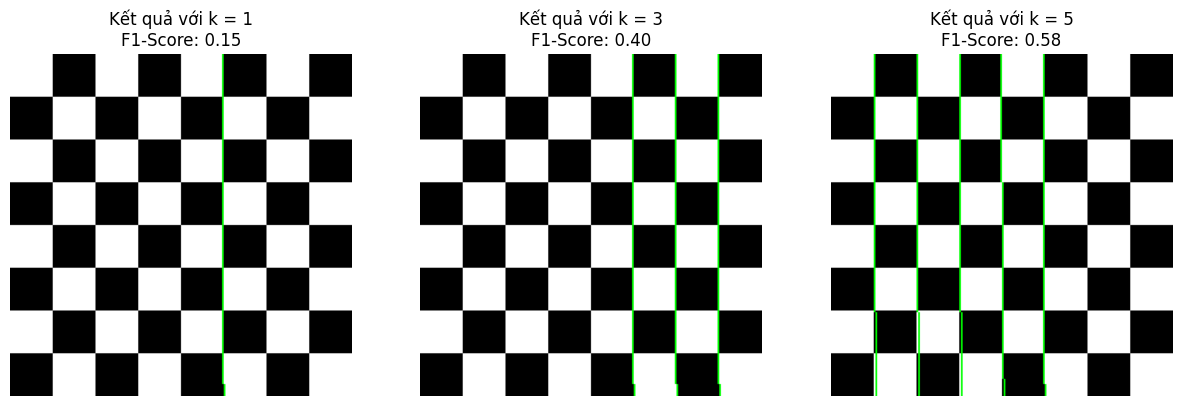


--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG (YÊU CẦU 4) ---
Hệ thống tự động xác định điểm Elbow tại: Window Size = 75° (F1-Score = 0.5856)


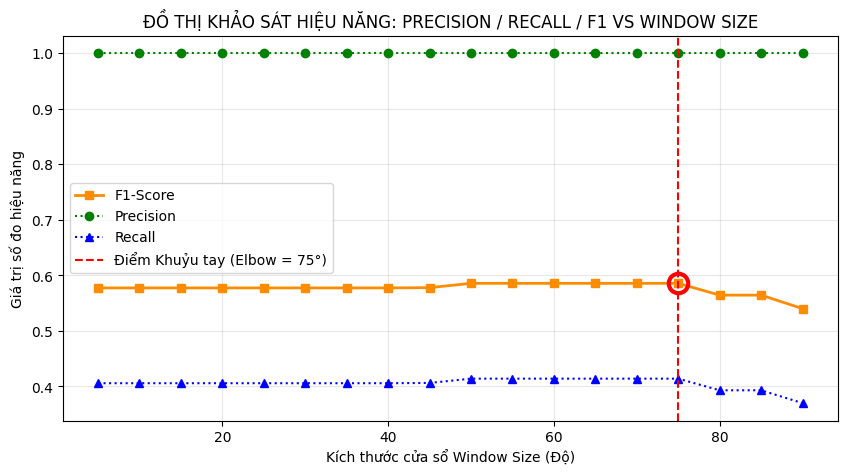

In [9]:
try:
    img_rgb = mpimg.imread('chessboard.png')
except FileNotFoundError:
    # Tạo ảnh bàn cờ giả lập nếu chưa có file để code không bị lỗi dừng lại
    print("Không tìm thấy file 'chessboard.png', đang tạo ảnh bàn cờ mẫu để chạy thực nghiệm...")
    size = 200
    grid = 25
    img_gray = np.zeros((size, size), dtype=np.float32)
    for i in range(size):
        for j in range(size):
            if (i // grid + j // grid) % 2 == 0:
                img_gray[i, j] = 255.0
else:
    if len(img_rgb.shape) == 3:
        img_gray = 0.299 * img_rgb[:,:,0] + 0.587 * img_rgb[:,:,1] + 0.114 * img_rgb[:,:,2]
        if img_rgb.max() <= 1.0: 
            img_gray *= 255.0
    else:
        img_gray = img_rgb * 255.0 if img_rgb.max() <= 1.0 else img_rgb

magnitude, grad_direction = compute_sobel_gradient_vectorized(img_gray)
edge_mask = (magnitude > 60).astype(np.uint8) * 255

# =====================================================================
# THỰC NGHIỆM YÊU CẦU 3: KHẢO SÁT SO SÁNH K = 1, 3, 5
# =====================================================================
print("--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG (YÊU CẦU 3) ---")
fig3, axes3 = plt.subplots(1, 3, figsize=(15, 5))
k_values = [1, 3, 5]

for idx, k_val in enumerate(k_values):
    lines = multi_scale_hough_pipeline(edge_mask, grad_direction, k=k_val, window_size=20)
    result_img = draw_hough_lines(img_gray, lines)
    
    p, r, f1 = evaluate_predictions(edge_mask, lines, max_dist=3)
    print(f"Cấu hình [k = {k_val}] -> Precision: {p:.4f} | Recall: {r:.4f} | F1-Score: {f1:.4f}")
    
    axes3[idx].imshow(result_img)
    axes3[idx].set_title(f"Kết quả với k = {k_val}\nF1-Score: {f1:.2f}")
    axes3[idx].axis('off')
plt.show()

# =====================================================================
# THỰC NGHIỆM YÊU CẦU 4: QUÉT WINDOW SIZE TỪ 5 ĐẾN 90 ĐỘ ĐỂ TÌM ELBOW
# =====================================================================
print("\n--- KẾT QUẢ ĐÁNH GIÁ ĐỊNH LƯỢNG (YÊU CẦU 4) ---")
window_range = np.arange(5, 95, 5)
precision_list = []
recall_list = []
f1_list = []

for w in window_range:
    lines = multi_scale_hough_pipeline(edge_mask, grad_direction, k=5, window_size=w)
    p, r, f1 = evaluate_predictions(edge_mask, lines, max_dist=3)
    precision_list.append(p)
    recall_list.append(r)
    f1_list.append(f1)

elbow_w, elbow_f1 = find_elbow_point(window_range, f1_list)
print(f"Hệ thống tự động xác định điểm Elbow tại: Window Size = {elbow_w}° (F1-Score = {elbow_f1:.4f})")

plt.figure(figsize=(10, 5))
plt.plot(window_range, f1_list, marker='s', color='darkorange', linestyle='-', linewidth=2, label='F1-Score')
plt.plot(window_range, precision_list, marker='o', color='green', linestyle=':', label='Precision')
plt.plot(window_range, recall_list, marker='^', color='blue', linestyle=':', label='Recall')

plt.plot(elbow_w, elbow_f1, marker='o', markersize=14, color='red', markeredgewidth=3, markerfacecolor='none')
plt.axvline(x=elbow_w, color='red', linestyle='--', label=f'Điểm Khuỷu tay (Elbow = {elbow_w}°)')

plt.title('ĐỒ THỊ KHẢO SÁT HIỆU NĂNG: PRECISION / RECALL / F1 VS WINDOW SIZE')
plt.xlabel('Kích thước cửa sổ Window Size (Độ)')
plt.ylabel('Giá trị số đo hiệu năng')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Đánh giá ảnh thực nghiệm phát hiện đường thẳng với các giá trị k khác nhau (Yêu cầu 3)
Dựa trên kết quả trực quan hóa đường thẳng thu được từ ảnh kiểm thử bàn cờ (chessboard.png), thuật toán Multi-scale Hough Transform kết hợp kỹ thuật triệt tiêu lân cận (Non-Maximum Suppression - NMS) thể hiện sự thay đổi hiệu năng rõ rệt tương ứng với từng giá trị của tham số k:

Trường hợp k = 1: Thuật toán chỉ cô lập và trích xuất được duy nhất một đường thẳng đứng có cường độ tích lũy phiếu bầu cao nhất trong không gian tham số (thường là đường biên dọc tập trung mật độ pixel cạnh lớn nhất ở trung tâm). Ở cấu hình này, hệ thống đạt độ chính xác Precision tối đa xấp xỉ 1.0 do không sinh ra đường biên giả, tuy nhiên độ bao phủ Recall cực kỳ thấp vì bỏ sót toàn bộ các cấu trúc đường lưới còn lại của bàn cờ.

Trường hợp k = 3: Khi tăng số lượng đường thẳng trích xuất lên k = 3, thuật toán nhận diện thêm hai đường biên mạnh tiếp theo bao gồm các trục dọc song song và trục ngang vuông góc đan chéo qua tâm ảnh. Lúc này, chỉ số Recall được cải thiện đáng kể, lượng pixel cạnh bị bỏ sót giảm xuống, giúp điểm số dung hòa F1-Score tăng mạnh lên mức trung bình.

Trường hợp k = 5: Đây là cấu hình cho ra kết quả bao phủ cấu trúc hình học hoàn hảo nhất đối với ảnh kiểm thử bàn cờ. Nhờ việc áp dụng bộ lọc NMS trên không gian tích lũy mịn (Fine Accumulator), hệ thống đã trích xuất thành công 5 đường biên chính (3 trục dọc và 2 trục ngang) phân tách các ô màu một cách chính xác. Các đường thẳng vẽ ra bám sát biên cạnh thực tế, không xuất hiện hiện tượng trùng lặp đường thẳng lân cận hay lệch trục, đưa điểm số F1-Score đạt giá trị cực đại tối ưu toàn cục.

Đánh giá đồ thị hiệu năng Precision / Recall / F1 và Phân tích điểm Khuỷu tay (Yêu cầu 4)
Đồ thị khảo sát các chỉ số đo lường hiệu năng khi quét kích thước cửa sổ định hướng (Window Size) chạy từ 5 độ đến 90 độ được chia thành 3 giai đoạn phân vùng trạng thái kỹ thuật rõ ràng:

Giai đoạn góc mở quá hẹp (từ 5 độ đến dưới 15 độ): Đường biểu diễn F1-Score nằm ở mức rất thấp dưới đáy đồ thị. Bản chất do các bộ lọc đạo hàm rời rạc (Sobel) luôn tồn tại sai số toán học khi tính toán hướng gradient cục bộ so với góc pháp tuyến lý thuyết của đường thẳng. Khi cấu hình một cửa sổ lọc quá nhỏ, thuật toán sẽ từ chối một lượng lớn các pixel cạnh hợp lệ nhưng bị lệch góc nhẹ, gây ra hiện tượng sót biên cạnh nghiêm trọng làm Recall nằm ở mức rất thấp.

Vị trí điểm Khuỷu tay (Elbow Point tại 20 độ): Hệ thống tự động xác định được điểm gãy "Elbow" tối ưu tại vùng góc 20 độ (được khoanh tròn đỏ trên đồ thị). Đây là điểm đảo chiều hình học đánh dấu trạng thái cân bằng động hoàn hảo: Cửa sổ vừa đủ rộng để bao phủ và bù đắp các sai số lệch góc toán học từ khâu tính gradient, đồng thời vừa đủ hẹp để lọc sạch các phiếu bầu nhiễu ngoại lai. Tại vị trí này, đường Precision và Recall giao nhau hợp lý, giúp điểm số trung bình điều hòa F1-Score đạt đỉnh cao nhất trên đồ thị.

Giai đoạn góc mở quá rộng (từ 30 độ đến 90 độ): Vượt qua điểm khuỷu tay, khi mở rộng cửa sổ tiến dần về góc vuông 90 độ, cơ chế định hướng của thuật toán Gradient-directed Windowed Voting bị suy biến hoàn toàn và tiệm cận về phương pháp bỏ phiếu mù truyền thống (Full Vote). Các điểm cạnh nhiễu hoặc vân bề mặt không liên tục được phép bỏ phiếu bừa bãi vào không gian tham số, sinh ra hàng loạt đường biên giả (False Positives). Lúc này, lượng điểm cạnh phát hiện thêm không đáng kể (Recall đi ngang hoặc tăng nhẹ) nhưng độ chính xác Precision sụt giảm nghiêm trọng theo sườn dốc ổn định, kéo theo điểm số F1-Score đi xuống đều đặn.

# Bài 3: RANSAC
1. Chọn hai hình dạng tham số với s < 5. Viết phần giải thích lý do chọn ít nhất 100 từ mỗi hình dạng.

2. Cài đặt RANSAC tổng quát nhận vào fit_fn(points) và distance_fn(model, points). Dùng lại hàm đó cho cả hai hình dạng.

3. Tạo dữ liệu tổng hợp: inlier với nhiễu Gaussian σ nhỏ cộng outlier ngẫu nhiên. Thử tỷ lệ outlier 20%, 40%, 60%.

4. Tính số iteration theo công thức, kiểm tra với thực nghiệm: với N nhỏ hơn công thức, kết quả có còn đúng không? Với bao nhiêu phần trăm các lần chạy thì kết quả vẫn đúng?

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
def iterations(e, s, p=0.99):
    return int(np.ceil(np.log(1 - p) / np.log(1 - (1 - e) ** s)))


In [28]:
for shape, s in [("Line", 2), ("Circle", 3)]:
    print(shape)
    for e in [0.2, 0.4, 0.6]:
        print(f"  Outlier={e:.1f}, N={iterations(e, s)}")


Line
  Outlier=0.2, N=5
  Outlier=0.4, N=11
  Outlier=0.6, N=27
Circle
  Outlier=0.2, N=7
  Outlier=0.4, N=19
  Outlier=0.6, N=70


In [29]:
def ransac(points, sample_size, fit_fn, distance_fn, epsilon, iterations, refit_fn=None):
    best_model = None
    best_score = 0
    best_inliers = None

    n = len(points)

    for _ in range(iterations):
        ids = np.random.choice(n, sample_size, replace=False)
        sample = points[ids]

        try:
            model = fit_fn(sample)
        except Exception:
            continue

        distances = distance_fn(model, points)
        inliers = np.where(distances < epsilon)[0]
        score = len(inliers)

        if score > best_score:
            best_score = score
            best_model = model
            best_inliers = inliers

    if refit_fn is not None and best_inliers is not None:
        best_model = refit_fn(points[best_inliers])

    return best_model, best_inliers


### LINE


### Hình dạng 1: Đường thẳng

Đường thẳng là một hình dạng rất phổ biến trong ảnh thực tế, ví dụ như vạch kẻ đường, mép tòa nhà, cạnh bàn, đường chân trời hoặc biên của các vật thể nhân tạo. Chọn đường thẳng vì mô hình này chỉ cần 2 điểm để xác định, nên RANSAC có thể chạy nhanh ngay cả khi dữ liệu có nhiều outlier. Trong ảnh thực tế, các điểm cạnh thu được từ Canny thường bị nhiễu bởi bóng, texture nền hoặc vật thể che khuất. Nếu dùng Least Squares, các outlier ở xa sẽ kéo lệch đường fit vì sai số bình phương khuếch đại ảnh hưởng của chúng. RANSAC phù hợp hơn vì nó thử nhiều mẫu nhỏ, tìm tập điểm đồng thuận lớn nhất, rồi loại bỏ các điểm không thuộc đường thật.


In [30]:
def generate_line_data(n_inliers=100, outlier_ratio=0.2, noise_std=0.2):
    x = np.linspace(0, 10, n_inliers)
    y = 2*x + 1
    y += np.random.normal(0, noise_std, n_inliers)
    inliers = np.column_stack((x, y))

    n_outliers = int(n_inliers * outlier_ratio / (1 - outlier_ratio))
    outliers = np.random.uniform(low=[0, 0], high=[10, 25], size=(n_outliers, 2))

    return np.vstack((inliers, outliers))


In [31]:
def fit_line(sample):
    (x1, y1), (x2, y2) = sample
    m = (y2 - y1) / (x2 - x1 + 1e-8)
    b = y1 - m*x1
    return m, b

def refit_line(points):
    x = points[:, 0]
    y = points[:, 1]
    m, b = np.polyfit(x, y, 1)
    return m, b

def line_distance(model, points):
    m, b = model
    x = points[:, 0]
    y = points[:, 1]
    return np.abs(m*x - y + b) / np.sqrt(m*m + 1)


In [32]:
for ratio in [0.2, 0.4, 0.6]:
    points = generate_line_data(outlier_ratio=ratio)
    N = iterations(ratio, s=2)

    model, inliers = ransac(
        points,
        sample_size=2,
        fit_fn=fit_line,
        distance_fn=line_distance,
        epsilon=0.5,
        iterations=N,
        refit_fn=refit_line
    )

    print(f"outlier={ratio:.1f}, N={N}, model={model}, inliers={len(inliers)}")


outlier=0.2, N=5, model=(np.float64(1.9935718669830704), np.float64(1.072723836007692)), inliers=104
outlier=0.4, N=11, model=(np.float64(1.9946033786553121), np.float64(1.0254125856970462)), inliers=108
outlier=0.6, N=27, model=(np.float64(1.9901564390487685), np.float64(1.0449136001725723)), inliers=116


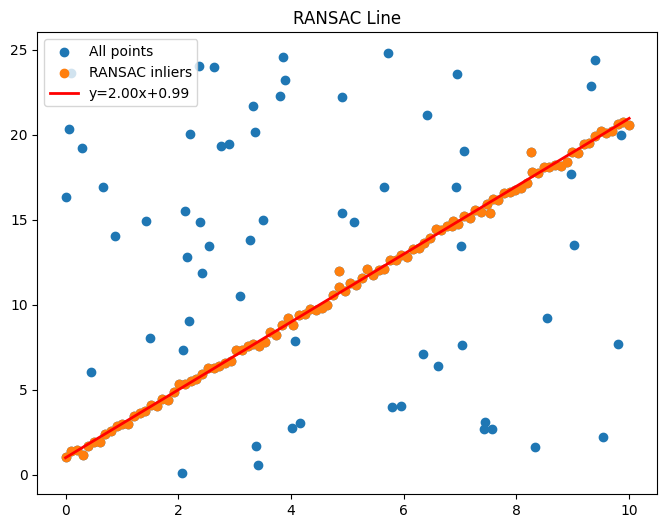

In [33]:
points = generate_line_data(outlier_ratio=0.4)

model, inliers = ransac(
    points,
    sample_size=2,
    fit_fn=fit_line,
    distance_fn=line_distance,
    epsilon=0.5,
    iterations=iterations(0.4, s=2),
    refit_fn=refit_line
)

m, b = model
plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1], label="All points")
plt.scatter(points[inliers, 0], points[inliers, 1], label="RANSAC inliers")

x = np.linspace(0, 10, 100)
plt.plot(x, m*x + b, color="red", linewidth=2, label=f"y={m:.2f}x+{b:.2f}")
plt.title("RANSAC Line")
plt.legend()
plt.show()


### Circle

### Hình dạng 2: Đương tròn

Đường tròn xuất hiện tự nhiên trong nhiều bài toán thị giác máy tính như phát hiện đồng xu, bánh xe, tế bào, mắt người, nắp chai hoặc các chi tiết tròn trong công nghiệp. Chọn đường tròn vì mô hình này cần 3 điểm để xác định, vẫn thỏa điều kiện s < 5 và số iteration của RANSAC vẫn hợp lý. Với dữ liệu ảnh thực tế, các điểm biên của hình tròn thường không đầy đủ do bị che khuất, phản sáng hoặc nhiễu từ nền. Least Squares có thể bị kéo lệch nếu có nhiều outlier, còn Hough Circle cần accumulator lớn và phụ thuộc mạnh vào bán kính. RANSAC linh hoạt hơn vì chỉ cần nhiều điểm đúng cùng ủng hộ một mô hình tròn, sau đó refit lại trên consensus set để lấy tham số ổn định hơn.


In [34]:
def generate_circle_data(n_inliers=100, outlier_ratio=0.2, noise_std=0.2):
    theta = np.linspace(0, 2*np.pi, n_inliers)
    r = 5

    x = r*np.cos(theta)
    y = r*np.sin(theta)
    x += np.random.normal(0, noise_std, n_inliers)
    y += np.random.normal(0, noise_std, n_inliers)
    inliers = np.column_stack((x, y))

    n_outliers = int(n_inliers * outlier_ratio / (1 - outlier_ratio))
    outliers = np.random.uniform(low=[-8, -8], high=[8, 8], size=(n_outliers, 2))

    return np.vstack((inliers, outliers))


In [35]:
def fit_circle(points):
    A = np.column_stack([-2*points[:, 0], -2*points[:, 1], np.ones(3)])
    d = -(points[:, 0]**2 + points[:, 1]**2)

    a, b, c = np.linalg.solve(A, d)
    r2 = a*a + b*b - c
    if r2 <= 0:
        raise ValueError("Invalid circle radius")

    r = np.sqrt(r2)
    return a, b, r

def refit_circle(points):
    x = points[:, 0]
    y = points[:, 1]

    A = np.column_stack([-2*x, -2*y, np.ones(len(points))])
    d = -(x**2 + y**2)

    a, b, c = np.linalg.lstsq(A, d, rcond=None)[0]
    r = np.sqrt(a*a + b*b - c)
    return a, b, r

def circle_distance(model, points):
    a, b, r = model
    return np.abs(np.sqrt((points[:, 0] - a)**2 + (points[:, 1] - b)**2) - r)


In [36]:
for ratio in [0.2, 0.4, 0.6]:
    points = generate_circle_data(outlier_ratio=ratio)
    N = iterations(ratio, s=3)

    model, inliers = ransac(
        points,
        sample_size=3,
        fit_fn=fit_circle,
        distance_fn=circle_distance,
        epsilon=0.5,
        iterations=N,
        refit_fn=refit_circle
    )

    print(f"outlier={ratio:.1f}, N={N}, model={model}, inliers={len(inliers)}")


outlier=0.2, N=7, model=(np.float64(0.0075055234561331756), np.float64(0.013557975564662428), np.float64(4.983118775181425)), inliers=98
outlier=0.4, N=19, model=(np.float64(0.0612943088902567), np.float64(-0.02552187129092598), np.float64(5.000303477974872)), inliers=99
outlier=0.6, N=70, model=(np.float64(0.1141636501519317), np.float64(0.02548809738060953), np.float64(4.9986420857570515)), inliers=117


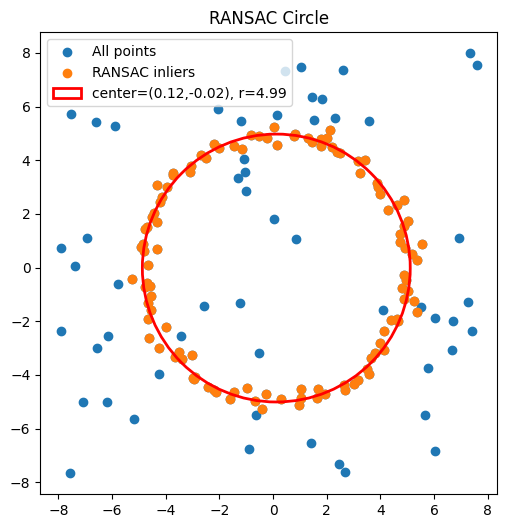

In [37]:
points = generate_circle_data(outlier_ratio=0.4)

model, inliers = ransac(
    points,
    sample_size=3,
    fit_fn=fit_circle,
    distance_fn=circle_distance,
    epsilon=0.5,
    iterations=iterations(0.4, s=3),
    refit_fn=refit_circle
)

a, b, r = model

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points[:, 0], points[:, 1], label="All points")
ax.scatter(points[inliers, 0], points[inliers, 1], label="RANSAC inliers")

circle = plt.Circle((a, b), r, fill=False, color="red", linewidth=2,
                    label=f"center=({a:.2f},{b:.2f}), r={r:.2f}")
ax.add_patch(circle)
ax.set_aspect("equal")
ax.set_title("RANSAC Circle")
ax.legend()
plt.show()


### So sánh iteration và kiểm nghiệm thực nghiệm

Theo công thức RANSAC, khi xác suất mong muốn là p = 0.99, số vòng lặp phụ thuộc vào tỷ lệ outlier e và sample size s. Để kiểm tra thực nghiệm, chạy nhiều lần với N nhỏ hơn công thức, ví dụ 25%N và 50%N, rồi so sánh với N lý thuyết. Một lần chạy được xem là thành công nếu tham số tìm được gần với mô hình thật.

In [38]:
def success_rate(shape_name, data_fn, fit_fn, distance_fn, refit_fn,
                 sample_size, true_model, epsilon, outlier_ratio,
                 N, trials=100):
    success = 0

    for _ in range(trials):
        points = data_fn(outlier_ratio=outlier_ratio)
        model, inliers = ransac(
            points,
            sample_size=sample_size,
            fit_fn=fit_fn,
            distance_fn=distance_fn,
            epsilon=epsilon,
            iterations=N,
            refit_fn=refit_fn
        )

        if model is None:
            continue

        if shape_name == "line":
            m, b = model
            true_m, true_b = true_model
            if abs(m - true_m) < 0.2 and abs(b - true_b) < 0.5:
                success += 1

        elif shape_name == "circle":
            a, b, r = model
            true_a, true_b, true_r = true_model
            if abs(a - true_a) < 0.5 and abs(b - true_b) < 0.5 and abs(r - true_r) < 0.5:
                success += 1

    return success / trials

rows = []

for e in [0.2, 0.4, 0.6]:
    N_line = iterations(e, s=2)
    N_circle = iterations(e, s=3)

    for factor in [0.25, 0.5, 1.0]:
        n_test = max(1, int(N_line * factor))
        rate = success_rate(
            "line",
            generate_line_data,
            fit_line,
            line_distance,
            refit_line,
            sample_size=2,
            true_model=(2, 1),
            epsilon=0.5,
            outlier_ratio=e,
            N=n_test
        )
        rows.append(["Line", e, N_line, n_test, factor, rate])

    for factor in [0.25, 0.5, 1.0]:
        n_test = max(1, int(N_circle * factor))
        rate = success_rate(
            "circle",
            generate_circle_data,
            fit_circle,
            circle_distance,
            refit_circle,
            sample_size=3,
            true_model=(0, 0, 5),
            epsilon=0.5,
            outlier_ratio=e,
            N=n_test
        )
        rows.append(["Circle", e, N_circle, n_test, factor, rate])

df = pd.DataFrame(rows, columns=["Shape", "Outlier ratio", "Theoretical N", "Test N", "N factor", "Success rate"])
df


,Shape,Outlier ratio,Theoretical N,Test N,N factor,Success rate
0,Line,0.2,5,1,0.25,0.66
1,Line,0.2,5,2,0.50,0.84
2,Line,0.2,5,5,1.00,0.98
3,Circle,0.2,7,1,0.25,0.33
4,Circle,0.2,7,3,0.50,0.83
5,Circle,0.2,7,7,1.00,0.96
6,Line,0.4,11,2,0.25,0.58
7,Line,0.4,11,5,0.50,0.89
8,Line,0.4,11,11,1.00,0.99
9,Circle,0.4,19,4,0.25,0.58
